<a href="https://colab.research.google.com/github/arsalanmontazeri/Arsalan-Montazeri/blob/AI-JOB-MARKET/Global_AI_Job_Market_%26_Salary_Trends_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# For displaying all of the columns in dataframes
pd.set_option('display.max_column',None)
# For data modeling
from xgboost import XGBClassifier
from xgboost import plot_importance
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score,\
f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_curve, roc_auc_score
# For saving models
import pickle
import plotly.express as px
import geopandas as gpd
import json

In [2]:
job_data=pd.read_csv('ai_job_dataset.csv')

In [3]:
job_data.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [4]:
job_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [5]:
job_data['posting_date']=pd.to_datetime(job_data['posting_date'])
job_data['application_deadline']=pd.to_datetime(job_data['application_deadline'])
job_data['post_day']=job_data['posting_date'].dt.day
job_data['post_month']=job_data['posting_date'].dt.month
job_data['post_year']=job_data['posting_date'].dt.year
job_data['deadline_day']=job_data['application_deadline'].dt.day
job_data['deadline_month']=job_data['application_deadline'].dt.month
job_data['deadline_year']=job_data['application_deadline'].dt.year
job_data['required_skills_list'] = job_data['required_skills'].str.split(r',\s*')

In [6]:
categorical_cols = [
    'job_title', 'salary_currency', 'experience_level', 'employment_type',
    'company_location', 'company_size', 'employee_residence', 'industry',
    'education_required', 'company_name'
]
for col in categorical_cols:
    job_data[col] = job_data[col].astype('category')

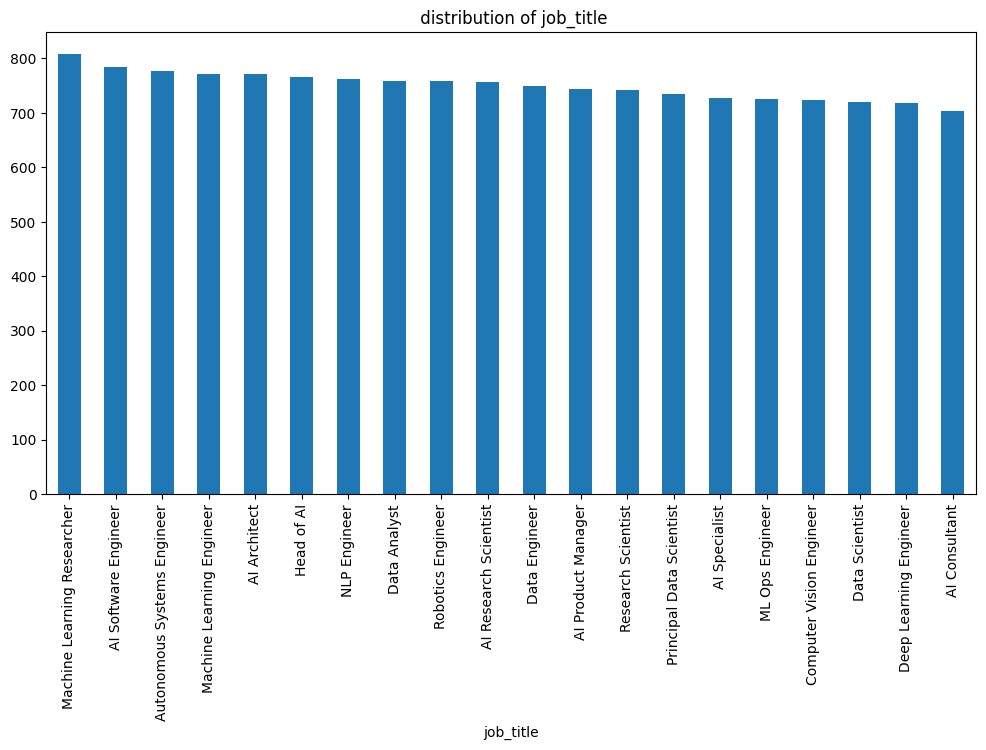

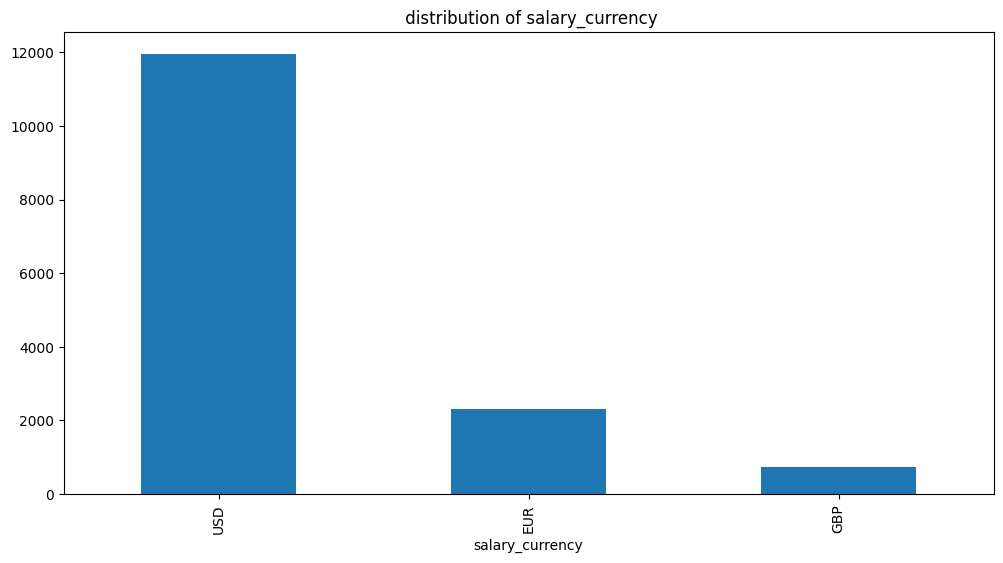

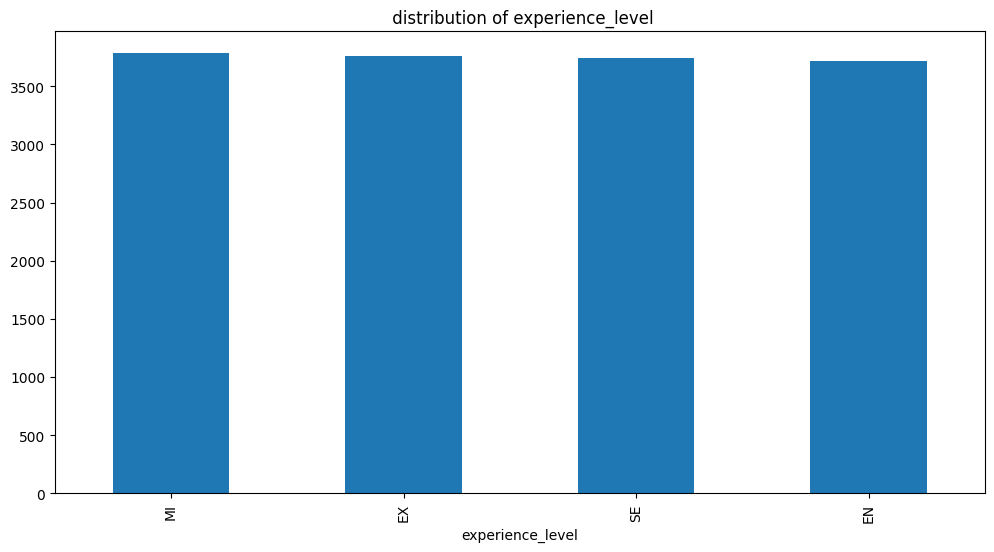

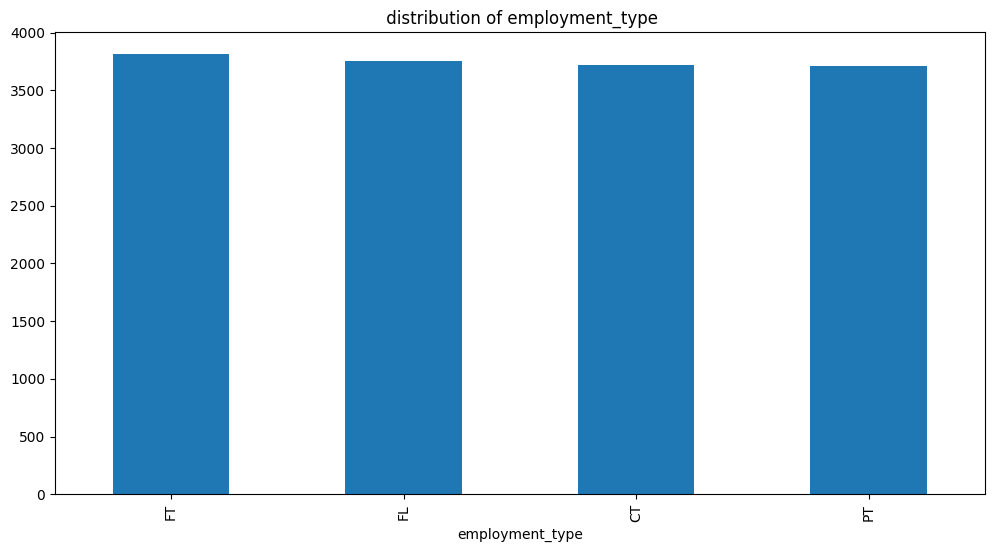

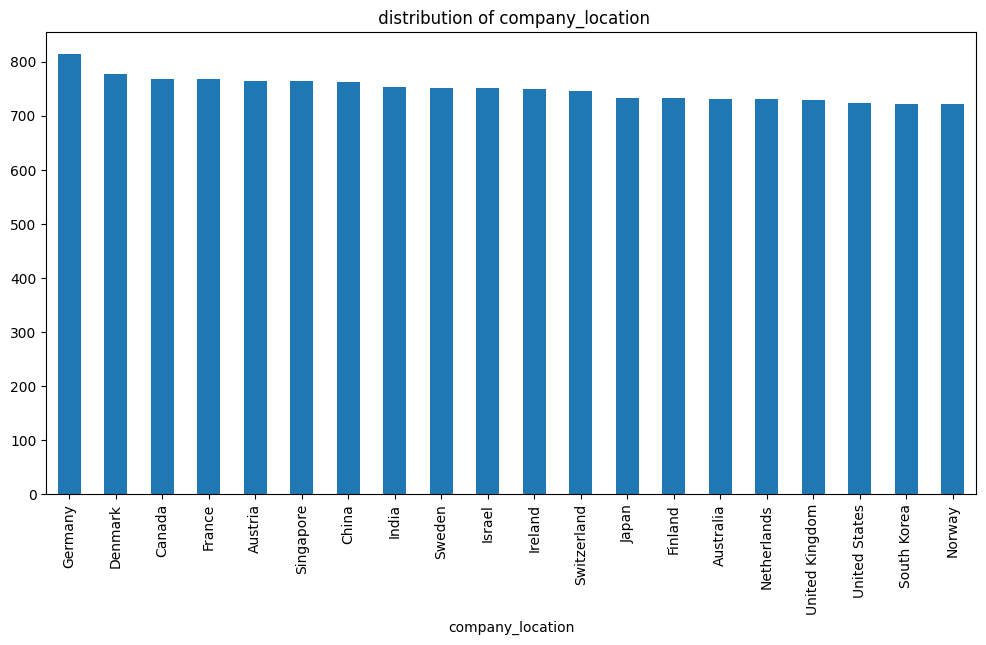

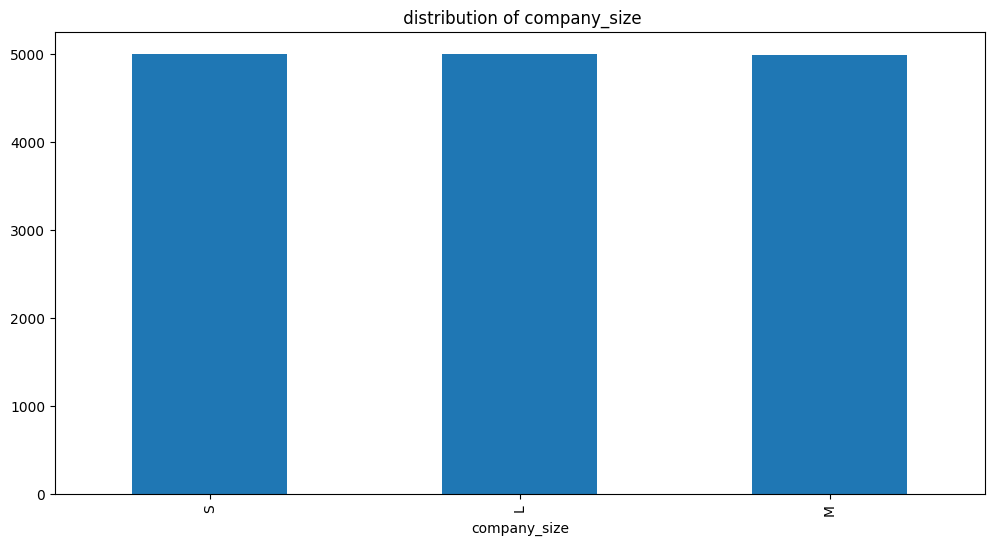

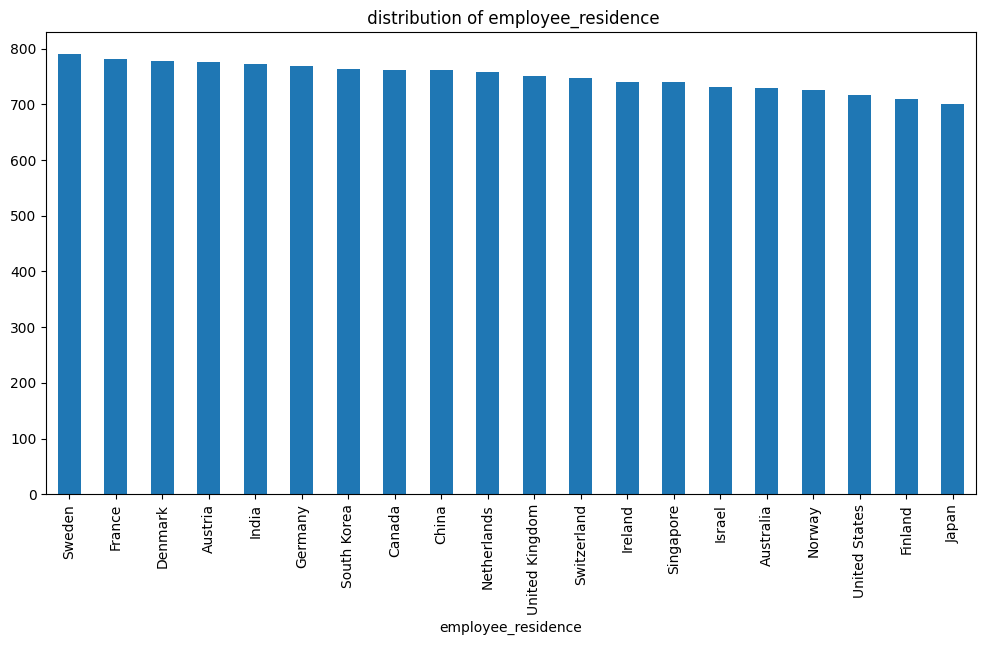

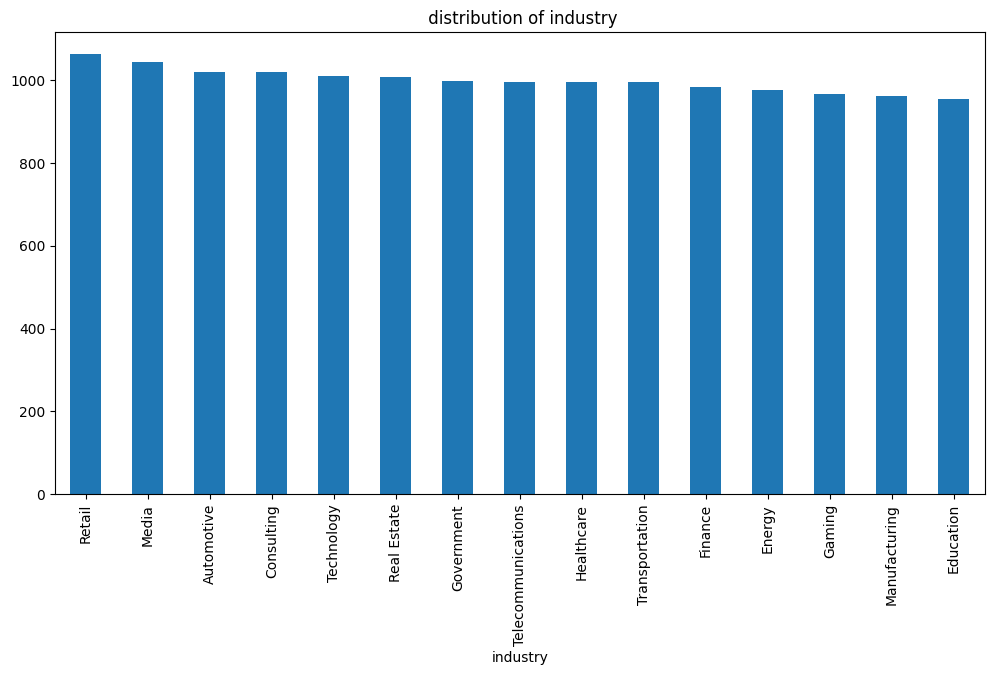

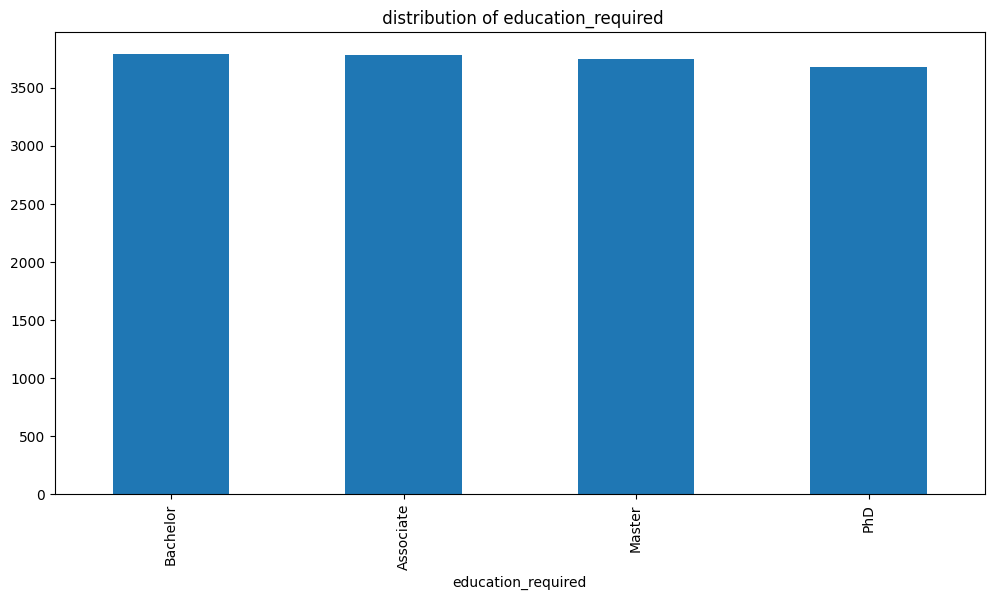

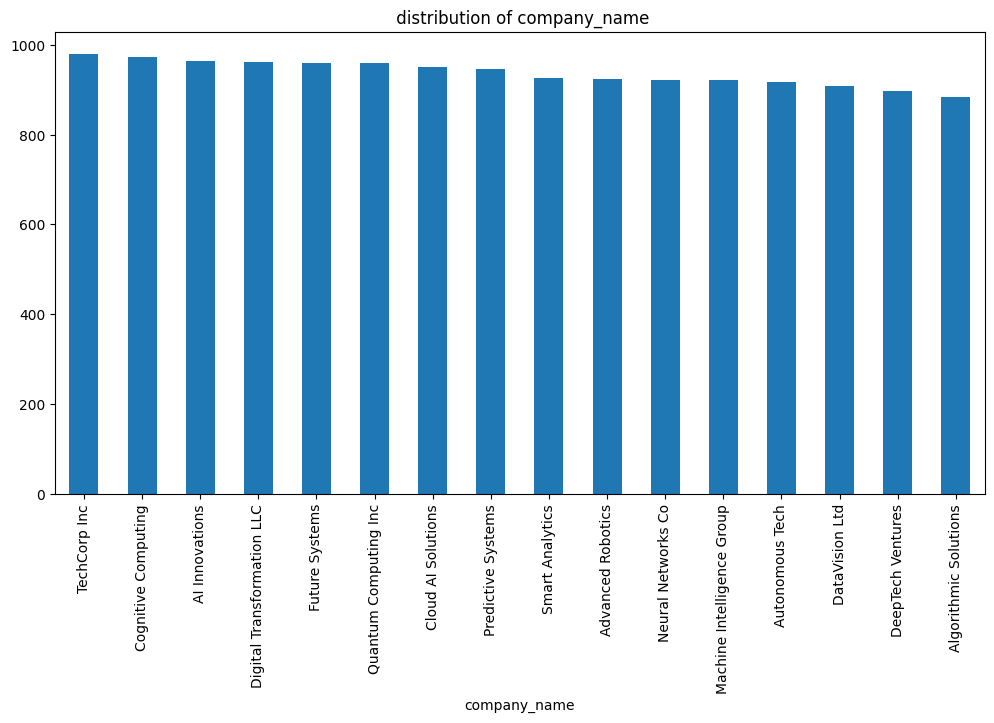

In [7]:
for col in categorical_cols:
  plt.figure(figsize=(12,6))
  job_data[col].value_counts().head(20).plot(kind='bar')
  plt.title(f' distribution of {col}')
  plt.show()

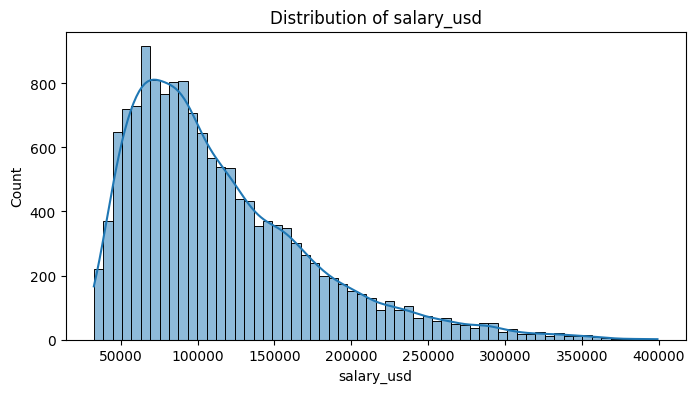

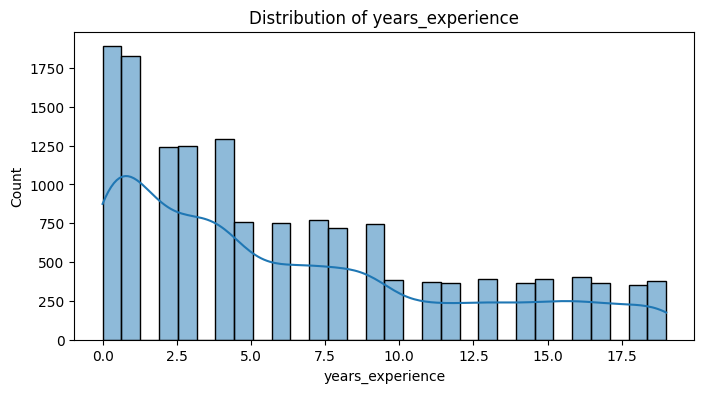

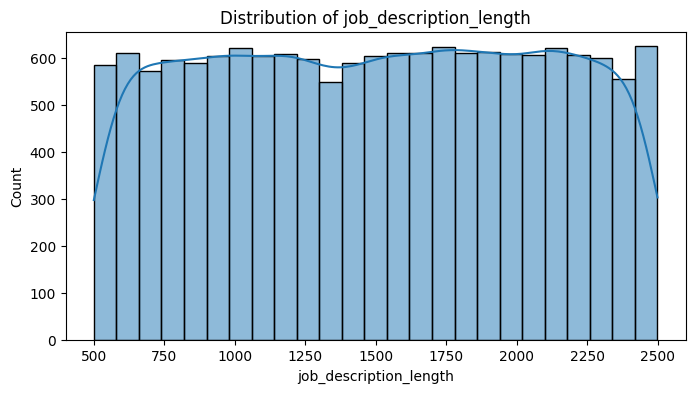

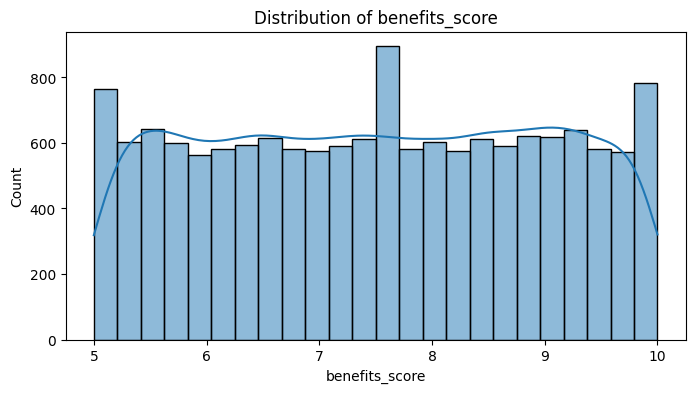

In [8]:
num_cols = ['salary_usd', 'years_experience', 'job_description_length', 'benefits_score']
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(job_data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

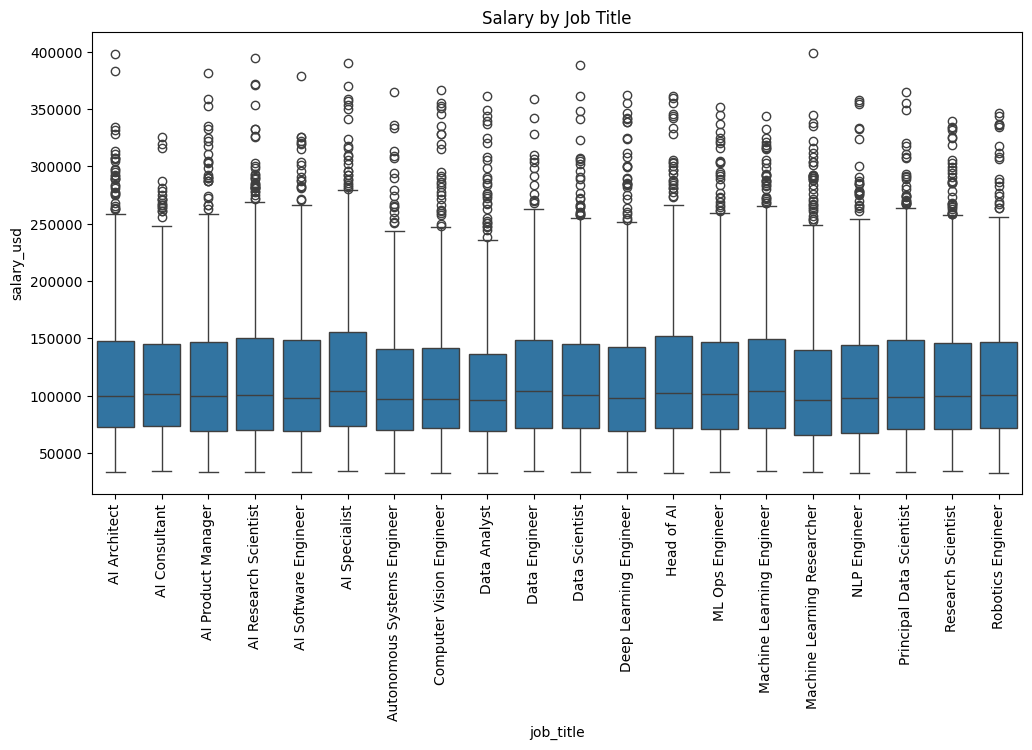

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(data=job_data, x='job_title', y='salary_usd')
plt.xticks(rotation=90)
plt.title('Salary by Job Title')
plt.show()

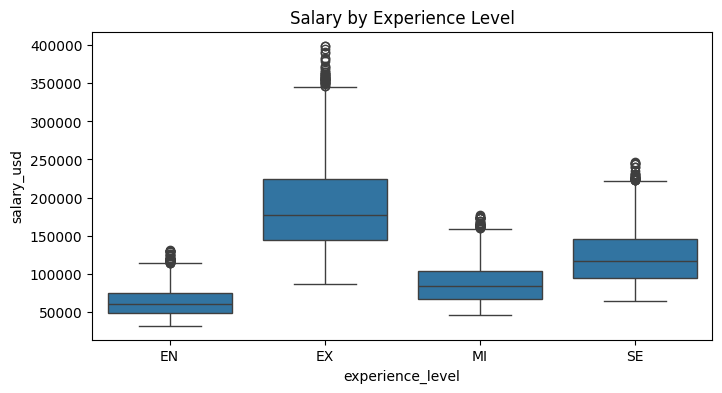

In [10]:
plt.figure(figsize=(8,4))
sns.boxplot(data=job_data, x='experience_level', y='salary_usd')
plt.title('Salary by Experience Level')
plt.show()

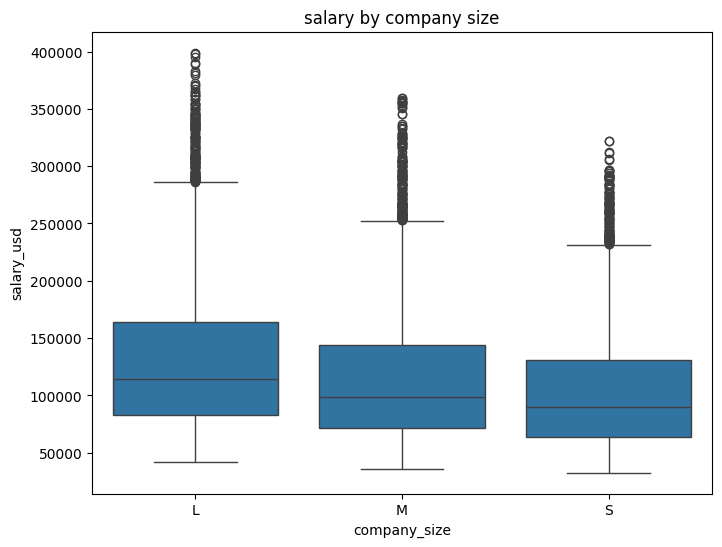

In [11]:
plt.figure(figsize=(8,6))
sns.boxplot(data=job_data,x='company_size',y='salary_usd')
plt.title('salary by company size')
plt.show()

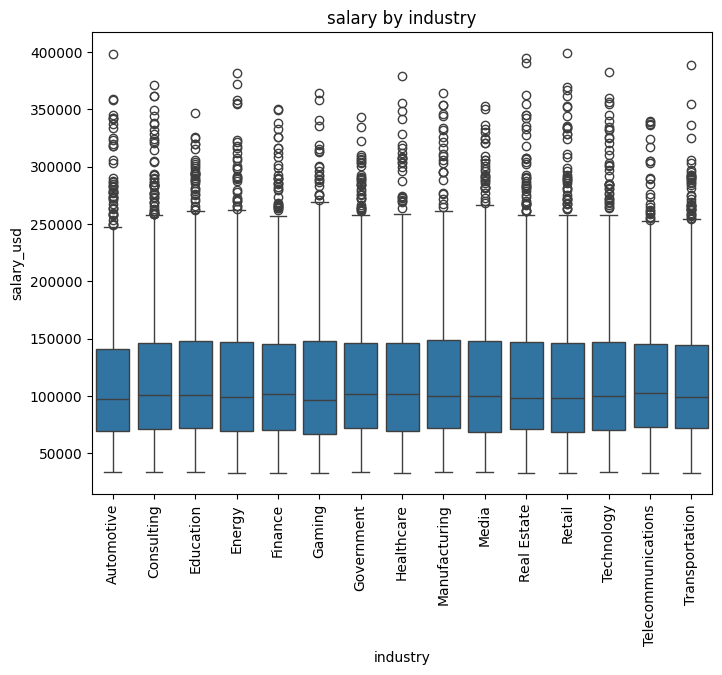

In [12]:
plt.figure(figsize=(8,6))
sns.boxplot(data=job_data,x='industry',y='salary_usd')
plt.title('salary by industry')
plt.xticks(rotation=90)
plt.show()

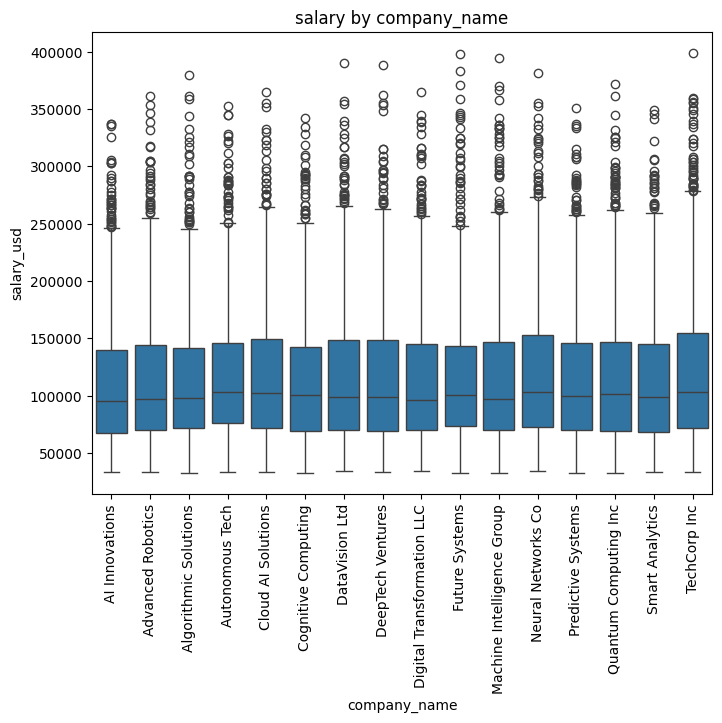

In [26]:
plt.figure(figsize=(8,6))
sns.boxplot(data=job_data,x='company_name',y='salary_usd')
plt.title('salary by company_name')
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='remote_ratio', ylabel='salary_usd'>

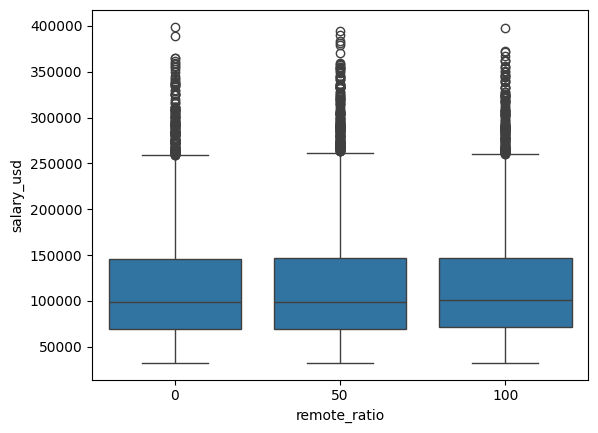

In [14]:
sns.boxplot(x='remote_ratio', y='salary_usd', data=job_data)

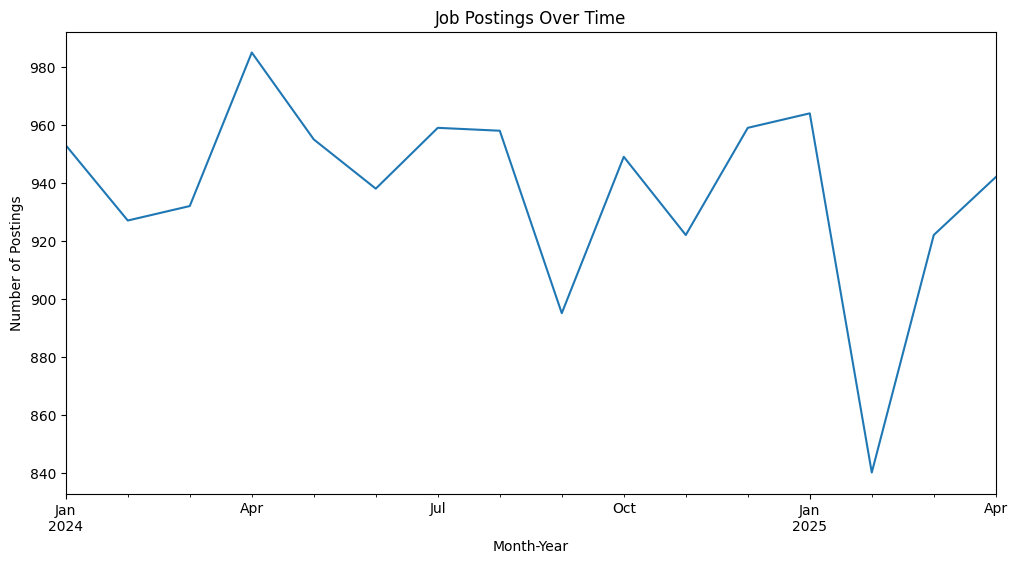

In [15]:
job_data['post_month_year'] = job_data['posting_date'].dt.to_period('M')
plt.figure(figsize=(12,6))
job_data['post_month_year'].value_counts().sort_index().plot()
plt.title('Job Postings Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Postings')
plt.show()

In [16]:
import geopandas as gpd
avg_salary_by_country = job_data.groupby('company_location')['salary_usd'].mean().reset_index().sort_values('salary_usd',ascending=False)
avg_salary_by_country

/tmp/ipython-input-16-768486319.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_salary_by_country = job_data.groupby('company_location')['salary_usd'].mean().reset_index().sort_values('salary_usd',ascending=False)


,company_location,salary_usd
17,Switzerland,170639.085791
4,Denmark,165652.249357
13,Norway,159490.533981
19,United States,146833.045580
18,United Kingdom,128720.186557
14,Singapore,128004.035340
12,Netherlands,126750.451436
16,Sweden,123559.753989
7,Germany,121810.143735
0,Australia,118238.887978


In [17]:
location_industry=job_data.groupby(['company_location','industry'])['salary_usd'].mean().reset_index().sort_values('salary_usd',ascending=False).head(10)
location_industry

/tmp/ipython-input-17-3888865776.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  location_industry=job_data.groupby(['company_location','industry'])['salary_usd'].mean().reset_index().sort_values('salary_usd',ascending=False).head(10)


,company_location,industry,salary_usd
267,Switzerland,Technology,206476.952381
258,Switzerland,Energy,189597.511111
69,Denmark,Media,184386.807692
264,Switzerland,Media,182790.905660
196,Norway,Consulting,178902.957447
269,Switzerland,Transportation,178701.423077
71,Denmark,Retail,177641.472727
73,Denmark,Telecommunications,177231.102041
256,Switzerland,Consulting,175360.037736
205,Norway,Real Estate,174477.309091


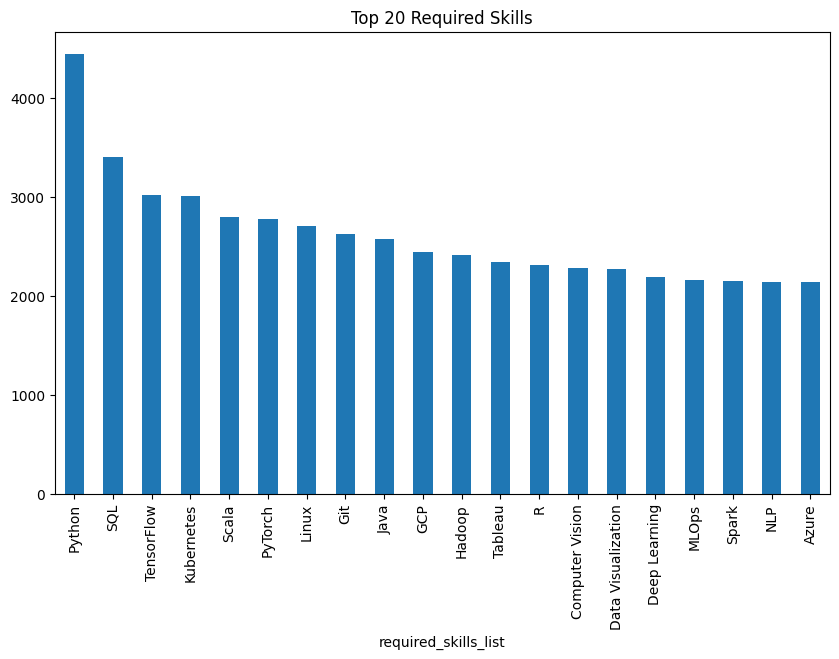

In [18]:
all_skills = job_data['required_skills_list'].explode()
top_skills = all_skills.value_counts().head(20)
plt.figure(figsize=(10,6))
top_skills.plot(kind='bar')
plt.title('Top 20 Required Skills')
plt.show()

In [19]:
exploded = job_data.explode('required_skills_list')
exploded.groupby('required_skills_list')['salary_usd'].mean().sort_values(ascending=False).head(10)


,salary_usd
required_skills_list,
Deep Learning,117242.074920
Scala,117207.426271
Docker,116751.924275
Git,116659.985177
NLP,116217.931469
Computer Vision,115897.875219
GCP,115799.629402
Hadoop,115749.505994
PyTorch,115527.204537


In [20]:
company_stats=job_data.groupby(['company_name','industry']).agg({'benefits_score':'mean','salary_usd':'mean'}).reset_index()
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
company_stats[['norm_salary', 'norm_benefits']] = scaler.fit_transform(
    company_stats[['salary_usd', 'benefits_score']]
)
company_stats['work_score'] = 0.5 * company_stats['norm_salary'] + 0.5 * company_stats['norm_benefits']
top_10_companies = company_stats.sort_values('work_score', ascending=False).head(10)
top_10_companies


/tmp/ipython-input-20-3969038950.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  company_stats=job_data.groupby(['company_name','industry']).agg({'benefits_score':'mean','salary_usd':'mean'}).reset_index()


,company_name,industry,benefits_score,salary_usd,norm_salary,norm_benefits,work_score
234,TechCorp Inc,Media,7.775000,135114.984375,1.000000,0.823883,0.911941
72,Cloud AI Solutions,Technology,7.721538,130013.430769,0.863348,0.776015,0.819682
227,TechCorp Inc,Education,7.672727,130438.981818,0.874747,0.732311,0.803529
238,TechCorp Inc,Telecommunications,7.647826,129981.217391,0.862485,0.710015,0.786250
84,Cognitive Computing,Media,7.762500,125839.178571,0.751535,0.812691,0.782113
205,Quantum Computing Inc,Real Estate,7.898182,121263.636364,0.628974,0.934176,0.781575
172,Neural Networks Co,Healthcare,7.779104,123940.552239,0.700678,0.827558,0.764118
153,Machine Intelligence Group,Energy,7.850980,120356.490196,0.604674,0.891913,0.748294
142,Future Systems,Healthcare,7.784483,122517.206897,0.662552,0.832373,0.747463
41,Algorithmic Solutions,Retail,7.872000,119288.980000,0.576080,0.910734,0.743407


/tmp/ipython-input-21-3843388272.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  company_loc_salary = job_data.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False).reset_index()
/tmp/ipython-input-21-3843388272.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  employee_residence_salary = job_data.groupby('employee_residence')['salary_usd'].mean().sort_values(ascending=False).reset_index()
/tmp/ipython-input-21-3843388272.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend

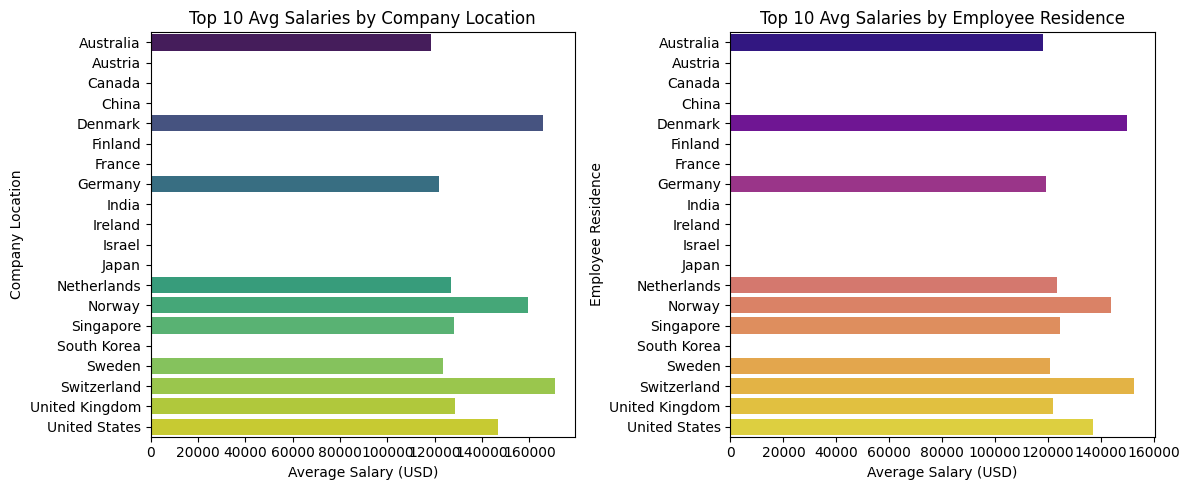

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by company location
company_loc_salary = job_data.groupby('company_location')['salary_usd'].mean().sort_values(ascending=False).reset_index()

# Group by employee residence
employee_residence_salary = job_data.groupby('employee_residence')['salary_usd'].mean().sort_values(ascending=False).reset_index()

# Plot both
plt.figure(figsize=(12, 5))

# Company location salary
plt.subplot(1, 2, 1)
sns.barplot(x='salary_usd', y='company_location', data=company_loc_salary.head(10), palette='viridis')
plt.title("Top 10 Avg Salaries by Company Location")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Company Location")

# Employee residence salary
plt.subplot(1, 2, 2)
sns.barplot(x='salary_usd', y='employee_residence', data=employee_residence_salary.head(10), palette='plasma')
plt.title("Top 10 Avg Salaries by Employee Residence")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Employee Residence")

plt.tight_layout()
plt.show()


In [22]:
job_data['offshore'] = job_data['company_location'] != job_data['employee_residence']
job_data['offshore'].value_counts().reset_index()

,offshore,count
0,False,10744
1,True,4256


In [23]:
exploded.groupby(['industry', 'required_skills_list']).size().unstack().fillna(0)


/tmp/ipython-input-23-2903395179.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  exploded.groupby(['industry', 'required_skills_list']).size().unstack().fillna(0)


required_skills_list,AWS,Azure,Computer Vision,Data Visualization,Deep Learning,Docker,GCP,Git,Hadoop,Java,Kubernetes,Linux,MLOps,Mathematics,NLP,PyTorch,Python,R,SQL,Scala,Spark,Statistics,Tableau,TensorFlow
industry,,,,,,,,,,,,,,,,,,,,,,,,
Automotive,142,137,125,145,137,135,179,182,166,159,188,189,158,132,155,181,306,149,227,180,143,122,156,230
Consulting,145,124,150,159,154,124,142,186,147,182,206,201,134,123,143,195,291,164,253,191,149,120,176,188
Education,139,151,146,130,128,135,149,147,139,174,209,187,133,123,136,180,301,149,224,190,132,105,135,208
Energy,118,148,162,153,133,115,159,185,147,157,199,169,157,113,147,175,273,157,234,179,143,114,145,203
Finance,142,140,155,142,140,111,169,170,154,170,212,207,145,128,133,179,290,139,204,180,140,124,160,198
Gaming,120,147,135,153,158,121,163,154,186,176,199,173,140,131,123,187,277,151,202,199,146,108,154,165
Government,149,137,171,150,139,115,169,174,157,166,210,185,148,134,142,185,272,161,208,199,138,123,149,212
Healthcare,140,130,169,158,150,134,169,180,131,150,201,139,137,132,144,183,298,147,243,188,147,104,168,204
Manufacturing,117,132,145,156,140,124,159,171,155,172,195,160,132,115,142,172,300,143,220,187,133,118,160,213


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import numpy as np # Import numpy to use np.sqrt for RMSE calculation

mlb = MultiLabelBinarizer()
skills_encoded = pd.DataFrame(
    mlb.fit_transform(job_data['required_skills_list']),
    columns=mlb.classes_,
    index=job_data.index
)

# ✅ Step 3: Combine skills with main dataset
df_model = pd.concat([job_data, skills_encoded], axis=1)

# ✅ Step 4: Select features and target
features = [
    'experience_level',
    'remote_ratio',
    'company_size',
    'industry'
] + list(skills_encoded.columns)

X = df_model[features]
y = np.log1p(df_model['salary_usd'])

# ✅ Step 5: Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ Step 6: Define categorical/numerical columns
categorical_cols = ['experience_level', 'company_size', 'industry']
numerical_cols = ['remote_ratio']

# ✅ Step 7: Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numerical_cols)
])

# ✅ Step 8: Random Forest Model
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = rf_pipeline.predict(X_test)

print("🌲 Random Forest Results")
# Calculate RMSE by taking the square root of the MSE
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, rf_preds)), 2))
print("R² Score:", round(r2_score(y_test, rf_preds), 4))

# ✅ Step 9: XGBoost Model
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
])

xgb_pipeline.fit(X_train, y_train)
xgb_preds = xgb_pipeline.predict(X_test)

print("\n🚀 XGBoost Results")
# Calculate RMSE by taking the square root of the MSE
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, xgb_preds)), 2))
print("R² Score:", round(r2_score(y_test, xgb_preds), 4))

🌲 Random Forest Results
RMSE: 0.28
R² Score: 0.6854

🚀 XGBoost Results
RMSE: 0.28
R² Score: 0.6917


In [42]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ✅ Step 1: Encode required_skills_list with MultiLabelBinarizer
mlb = MultiLabelBinarizer()
skills_encoded = pd.DataFrame(
    mlb.fit_transform(job_data['required_skills_list']),
    columns=mlb.classes_,
    index=job_data.index
)

# ✅ Step 2: Combine skills with main dataset
df_model = pd.concat([job_data, skills_encoded], axis=1)

# ✅ Step 3: Define features and target
features = [
    'experience_level',
    'remote_ratio',
    'company_size',
    'industry'
] + list(skills_encoded.columns)

X = df_model[features]
y = np.log1p(df_model['salary_usd'])  # log-transform salary

# ✅ Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ Step 5: Preprocessing
categorical_features = [
    'job_title', 'salary_currency', 'experience_level', 'employment_type',
    'company_location', 'company_size', 'employee_residence',
    'education_required', 'industry'
]
numerical_cols = ['remote_ratio']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ('num', 'passthrough', numerical_cols)
])

# ✅ Step 6: Train Random Forest (baseline)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
rf_preds = np.expm1(rf_pipeline.predict(X_test))  # Convert back from log-scale
y_true = np.expm1(y_test)

# ✅ Evaluate Random Forest
print("🌲 Random Forest Results")
print("RMSE:", round(np.sqrt(mean_squared_error(y_true, rf_preds)), 2))
print("R² Score:", round(r2_score(y_true, rf_preds), 4))

# ✅ Step 7: Hyperparameter tuning for XGBoost
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=params,
    n_iter=20,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

# ✅ Step 8: Create XGBoost pipeline with tuning
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', search)
])

xgb_pipeline.fit(X_train, y_train)
xgb_preds = np.expm1(xgb_pipeline.predict(X_test))  # Convert back from log-scale

# ✅ Evaluate Tuned XGBoost
print("\n🚀 Tuned XGBoost Results")
print("RMSE:", round(np.sqrt(mean_squared_error(y_true, xgb_preds)), 2))
print("R² Score:", round(r2_score(y_true, xgb_preds), 4))

# ✅ Best hyperparameters found
print("\nBest Hyperparameters for XGBoost:")
print(xgb_pipeline.named_steps['model'].best_params_)


🌲 Random Forest Results
RMSE: 37097.49
R² Score: 0.6227
Fitting 3 folds for each of 20 candidates, totalling 60 fits

🚀 Tuned XGBoost Results
RMSE: 36309.74
R² Score: 0.6385

Best Hyperparameters for XGBoost:
{'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
